Acoustic inter-speaker variability (std of F1/F2 across all tokens per phoneme):
         F1_norm  F2_norm
phoneme                  
a          0.424    0.527
e          0.229    0.557
i          0.209    0.613
o          0.113    0.283
u          0.185    0.467
y          0.380    0.540
ø          0.150    0.377
ɑ          0.281    0.283
ə          0.493    0.460
ɛ          0.187    0.553

Neural inter-speaker variability (mean pairwise cosine distance per phoneme):
model    whisper_layer4  xlsr_layer3
phoneme                             
a                 0.739        0.405
e                 0.794        0.615
i                 0.719        0.524
o                 0.871        0.560
u                 0.884        0.708
y                 0.885        0.720
ø                 0.781        0.553
ɑ                 0.856        0.416
ə                 0.927        0.768
ɛ                 0.822        0.589


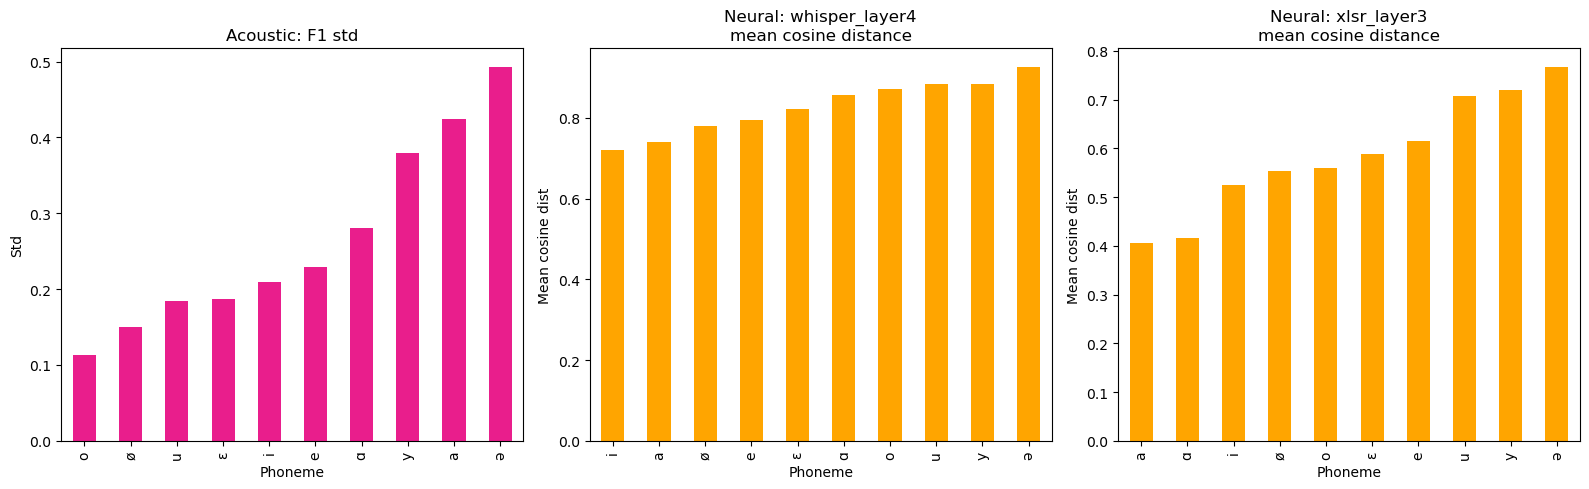

Saved


In [1]:
import os
os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/features/features_acoustic_norm.csv")

VOWELS = ["a", "e", "i", "o", "u", "y", "ø", "ɛ", "ɑ", "ə"]

# acoustic inter-speaker variability
# for each phoneme, compute std of F1_norm and F2_norm across speakers
acoustic_var = df[df["phoneme"].isin(VOWELS)].groupby("phoneme")[["F1_norm", "F2_norm"]].std()
print("Acoustic inter-speaker variability (std of F1/F2 across all tokens per phoneme):")
print(acoustic_var.round(3).to_string())

# neural inter-speaker variability
# for each phoneme, compute mean pairwise cosine distance across speakers
MODELS = {
    "whisper_layer4":  "data/features/features_whisper_layer4_pca.npz",
    "xlsr_layer3":    "data/features/features_xlsr_layer3_pca.npz",
}

neural_var_rows = []

for model_name, npz_path in MODELS.items():
    data    = np.load(npz_path)
    X       = data["clustering"]
    norms   = np.linalg.norm(X, axis=1, keepdims=True)
    X_norm  = X / np.maximum(norms, 1e-8)

    for phoneme in VOWELS:
        mask = df["phoneme"].values == phoneme
        X_ph = X_norm[mask]
        if len(X_ph) < 2:
            continue
        # sample max 300 for speed
        X_ph = X_ph[:300]
        # mean pairwise cosine distance = 1 - cosine similarity
        sim  = X_ph @ X_ph.T
        upper = sim[np.triu_indices(len(X_ph), k=1)]
        mean_dist = 1 - np.mean(upper)
        neural_var_rows.append({
            "model":    model_name,
            "phoneme":  phoneme,
            "mean_cosine_dist": round(mean_dist, 4),
        })

neural_var = pd.DataFrame(neural_var_rows).pivot(index="phoneme", columns="model", values="mean_cosine_dist")
print("\nNeural inter-speaker variability (mean pairwise cosine distance per phoneme):")
print(neural_var.round(3).to_string())

# plot comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

acoustic_var["F1_norm"].sort_values().plot(kind="bar", ax=axes[0], color="#e91e8c")
axes[0].set_title("Acoustic: F1 std")
axes[0].set_xlabel("Phoneme")
axes[0].set_ylabel("Std")

for ax, model in zip(axes[1:], MODELS.keys()):
    neural_var[model].sort_values().plot(kind="bar", ax=ax, color="#FFA500")
    ax.set_title(f"Neural: {model}\nmean cosine distance")
    ax.set_xlabel("Phoneme")
    ax.set_ylabel("Mean cosine dist")

plt.tight_layout()
plt.savefig("results/figures/interspeaker_variability.png", dpi=150)
plt.show()
print("Saved")